# VolEdge — Analysis Notebook

This notebook produces the two headline results referenced in the README:

1. **Implied volatility smile** — back out IV from an options chain and
   show the characteristic smile/skew shape.
2. **Delta-hedging error vs. rebalancing frequency** — quantify how
   discretization error in dynamic hedging shrinks as you rebalance
   more often.

It also sanity-checks the three pricers (Black-Scholes, binomial tree,
Monte Carlo) against each other before using them for anything else.

**Note on data**: this notebook uses a synthetic options chain (constructed
from a parametric vol-skew function) rather than a live pull, so the plots
below are reproducible offline and don't depend on market hours or a
network connection. The live version — pulling a real chain via
`yfinance` and running the same IV solver on it — is what `streamlit_app.py`
does; run that for live data. See README "Limitations" for why this
distinction matters.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.pricing.black_scholes import bs_call, bs_put, OptionType
from src.pricing.binomial_tree import binomial_price
from src.pricing.monte_carlo import mc_price
from src.implied_vol import implied_volatility
from src.hedging import hedging_error_vs_frequency

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Pricer cross-check

All three pricers should agree closely for a plain-vanilla European call.

In [2]:
S, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

bs = bs_call(S, K, T, r, sigma)
tree = binomial_price(S, K, T, r, sigma, n_steps=500, option_type=OptionType.CALL)
mc = mc_price(S, K, T, r, sigma, n_paths=200_000, seed=42)

print(f"Black-Scholes:  {bs:.4f}")
print(f"Binomial tree:  {tree:.4f}  (diff: {abs(tree - bs):.5f})")
print(f"Monte Carlo:    {mc.price:.4f} +/- {1.96*mc.std_error:.4f} (95% CI)")

Black-Scholes:  10.4506
Binomial tree:  10.4466  (diff: 0.00400)
Monte Carlo:    10.4763 +/- 0.0649 (95% CI)


## 2. Binomial tree convergence to Black-Scholes

As the number of steps grows, the CRR tree price should converge to the
closed-form Black-Scholes price. This is the core numerical-correctness
check for the tree pricer (also enforced in `tests/test_pricing.py`).

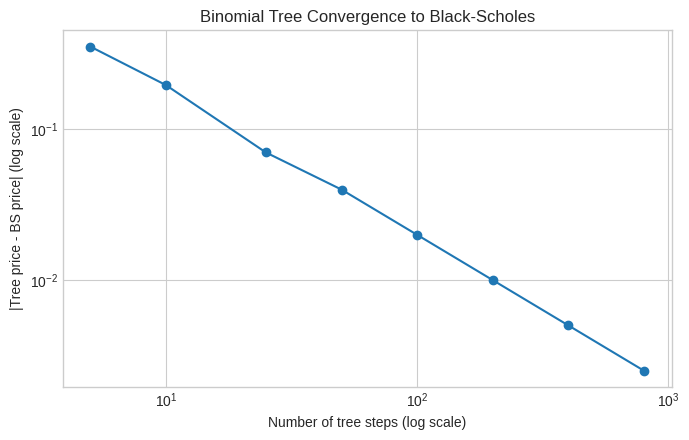

In [3]:
step_counts = [5, 10, 25, 50, 100, 200, 400, 800]
errors = [abs(binomial_price(S, K, T, r, sigma, n_steps=n) - bs) for n in step_counts]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(step_counts, errors, marker="o")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of tree steps (log scale)")
ax.set_ylabel("|Tree price - BS price| (log scale)")
ax.set_title("Binomial Tree Convergence to Black-Scholes")
fig.tight_layout()
fig.savefig("../assets/convergence.png", dpi=150)
plt.show()

## 3. Implied volatility smile

Construct a synthetic options chain with a realistic skew (OTM puts /
ITM calls priced with higher implied vol than ATM, matching the typical
equity index skew shape), then run the IV solver strike-by-strike to
recover the smile.

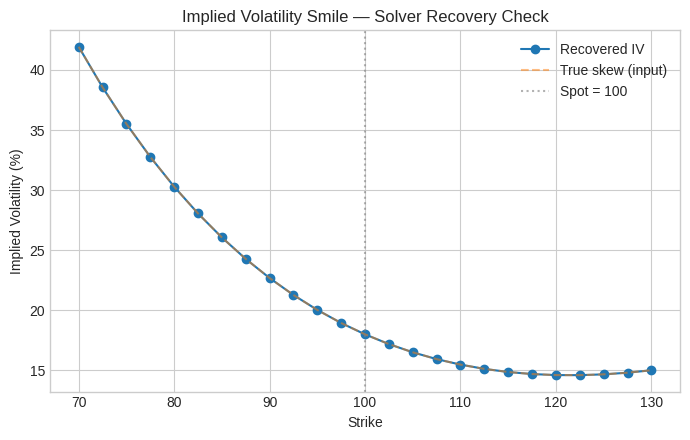

Recovered 25/25 strikes.
Max abs error vs. true input vol: 0.000002


In [4]:
spot = 100.0
expiry_T = 0.25
risk_free = 0.045
strikes = np.arange(70, 131, 2.5)


def synthetic_skew(strike: float, spot: float) -> float:
    """A simple parametric skew: higher IV for OTM puts (low strikes),
    a smile-shaped bump for both tails, roughly matching equity-index
    skew shape. Purely illustrative, not fit to any real market."""
    moneyness = np.log(strike / spot)
    atm_vol = 0.18
    skew_slope = -0.35     # negative slope: downside strikes trade richer
    smile_curvature = 0.9  # convexity, tails higher than ATM
    return atm_vol + skew_slope * moneyness + smile_curvature * moneyness**2


true_vols = [synthetic_skew(k, spot) for k in strikes]
synthetic_prices = [
    bs_call(spot, k, expiry_T, risk_free, v) if k >= spot else bs_put(spot, k, expiry_T, risk_free, v)
    for k, v in zip(strikes, true_vols)
]

recovered_strikes, recovered_ivs = [], []
for k, price in zip(strikes, synthetic_prices):
    opt_type = OptionType.CALL if k >= spot else OptionType.PUT
    result = implied_volatility(price, spot, k, expiry_T, risk_free, opt_type)
    if result.converged:
        recovered_strikes.append(k)
        recovered_ivs.append(result.iv)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recovered_strikes, [v * 100 for v in recovered_ivs], marker="o", label="Recovered IV")
ax.plot(strikes, [v * 100 for v in true_vols], "--", alpha=0.5, label="True skew (input)")
ax.axvline(spot, color="gray", linestyle=":", alpha=0.6, label=f"Spot = {spot:.0f}")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("Implied Volatility Smile — Solver Recovery Check")
ax.legend()
fig.tight_layout()
fig.savefig("../assets/vol_smile.png", dpi=150)
plt.show()

print(f"Recovered {len(recovered_strikes)}/{len(strikes)} strikes.")
max_err = max(abs(a - b) for a, b in zip(recovered_ivs, true_vols[: len(recovered_ivs)]))
print(f"Max abs error vs. true input vol: {max_err:.6f}")

## 4. Delta-hedging error vs. rebalancing frequency

Sell an ATM call, delta-hedge it dynamically under GBM, and measure the
standard deviation of hedging P&L at expiry across simulated paths, for
a range of rebalancing frequencies. Theory says this should shrink
monotonically as rebalancing gets more frequent (residual error from
discrete- vs. continuous-time hedging).

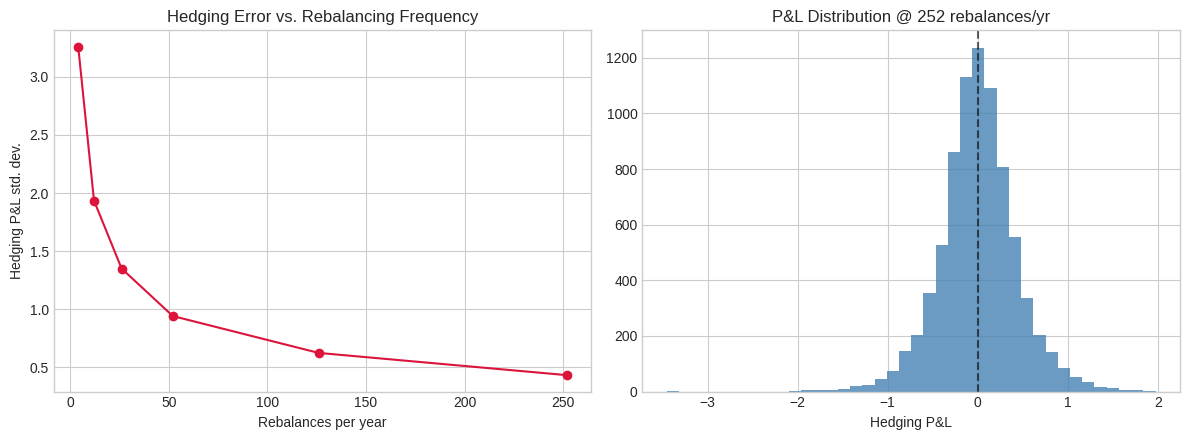

rebalances/yr=   4   std=3.2599   mean=-0.0480
rebalances/yr=  12   std=1.9353   mean=-0.0390
rebalances/yr=  26   std=1.3500   mean=-0.0183
rebalances/yr=  52   std=0.9408   mean=-0.0012
rebalances/yr= 126   std=0.6234   mean=-0.0027
rebalances/yr= 252   std=0.4318   mean=+0.0060


In [5]:
rebalance_freqs = [4, 12, 26, 52, 126, 252]
hedge_results = hedging_error_vs_frequency(
    S0=100, K=100, T=1.0, r=0.05, sigma=0.20,
    rebalance_counts=rebalance_freqs,
    option_type=OptionType.CALL,
    n_paths=8000,
    seed=42,
)

freqs = sorted(hedge_results.keys())
stds = [hedge_results[f].std for f in freqs]
means = [hedge_results[f].mean for f in freqs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(freqs, stds, marker="o", color="crimson")
ax1.set_xlabel("Rebalances per year")
ax1.set_ylabel("Hedging P&L std. dev.")
ax1.set_title("Hedging Error vs. Rebalancing Frequency")

ax2.hist(hedge_results[freqs[-1]].pnl, bins=40, color="steelblue", alpha=0.8)
ax2.axvline(0, color="black", linestyle="--", alpha=0.6)
ax2.set_xlabel("Hedging P&L")
ax2.set_title(f"P&L Distribution @ {freqs[-1]} rebalances/yr")

fig.tight_layout()
fig.savefig("../assets/hedging_error.png", dpi=150)
plt.show()

for f, s, m in zip(freqs, stds, means):
    print(f"rebalances/yr={f:4d}   std={s:.4f}   mean={m:+.4f}")

## Takeaways

- The binomial tree converges to Black-Scholes at the expected rate as
  step count increases, and Monte Carlo brackets the closed-form price
  within its confidence interval — cross-validating all three pricers.
- The IV solver recovers an input skew to within a small tolerance
  across strikes, including the low-vega tails where Newton-Raphson
  alone would fail (handled by the Brent fallback in `implied_vol.py`).
- Hedging error (P&L std. dev.) falls monotonically as rebalancing
  frequency increases, consistent with discrete-hedging theory. Mean
  P&L stays near zero throughout — the simulation is a variance story,
  not a directional edge, exactly as it should be under a correctly
  specified model.